In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df= pd.read_csv('/content/SampleSuperstore.csv')

In [ ]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub_Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.96,2.0,0.00,41.91
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.94,3.0,0.00,219.58
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.62,2.0,0.00,6.87
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.58,5.0,0.45,-383.03
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.37,2.0,0.20,2.52


In [ ]:
df.tail()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub_Category,Sales,Quantity,Discount,Profit
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.25,3.0,0.2,4.10
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.96,2.0,0.0,15.63
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.58,2.0,0.2,19.39
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.60,4.0,0.0,13.32
9993,Second Class,Consumer,United States,Westminster,California,92683,West,Office Supplies,Appliances,243.16,2.0,0.0,72.95


In [ ]:
df.shape

(9994, 13)

In [ ]:
df.dtypes

,0
Ship Mode,object
Segment,object
Country,object
City,object
State,object
Postal Code,int64
Region,object
Category,object
Sub_Category,object
Sales,float64


In [ ]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub_Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub_Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   float64
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 1015.1+ KB


In [ ]:
df.duplicated().sum()

np.int64(17)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(9977, 13)

In [ ]:
df.isnull().sum()

,0
Ship Mode,0
Segment,0
Country,0
City,0
State,0
Postal Code,0
Region,0
Category,0
Sub_Category,0
Sales,0


In [ ]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9977.000000,9977.000000,9977.000000,9977.000000,9977.000000
mean,55154.964117,230.148924,3.790719,0.156278,28.690207
std,32058.266816,623.721439,2.226657,0.206455,234.457935
min,1040.000000,0.440000,1.000000,0.000000,-6599.980000
25%,23223.000000,17.300000,2.000000,0.000000,1.730000
50%,55901.000000,54.820000,3.000000,0.200000,8.670000
75%,90008.000000,209.970000,5.000000,0.200000,29.370000
max,99301.000000,22638.480000,14.000000,0.800000,8399.980000


In [ ]:
# TOTAL SALES
total_sales=df['Sales'].sum()
print("Total Sales: ", total_sales)

Total Sales:  2296195.81


In [ ]:
# TOTAL PROFIT
total_profit=df['Profit'].sum()

print("Total Profit: ", total_profit)

Total Profit:  286242.2


In [ ]:
df['Quantity']=df['Quantity'].astype(int)


In [ ]:
df['Quantity'].dtype

dtype('int64')

In [ ]:
# AVERAGE SALES
average=df['Sales'].mean()
print('Avg Sales :' , round(average,2))

Avg Sales : 230.15


In [ ]:
# TOTAL QUANTITY
total_quantity=df['Quantity'].sum()
print("Total Quantity: ", total_quantity)

Total Quantity:  37820


In [ ]:
# PROFIT MARGIN
profit_margin=(total_profit/total_sales)*100
print("Profit Margin: ", round(profit_margin,2))

Profit Margin:  12.47


In [ ]:
#CATEGORY ANALYSIS
category_analysis=df.groupby('Category')[['Sales','Profit']].sum()
print(category_analysis)

                     Sales     Profit
Category                             
Furniture        741306.50   18421.79
Office Supplies  718735.21  122364.75
Technology       836154.10  145455.66


In [ ]:
# BEST CATEGORY IN THESE
best_sales_category=category_analysis['Sales'].idxmax()
best_profit_category=category_analysis['Profit'].idxmax()

print("Best Sales Category: ", best_sales_category)
print("Best Profit Category: ", best_profit_category)

Best Sales Category:  Technology
Best Profit Category:  Technology


In [ ]:
# ANALYSIS PERFORMANCE by REGION
region_analysis=df.groupby('Region')[['Sales','Profit']].sum()
print(region_analysis)

             Sales     Profit
Region                       
Central  500782.85   39655.97
East     678435.32   91506.37
South    391721.90   46749.71
West     725255.74  108330.15


In [ ]:
# BEST REGION IN THESE
best_profit_region=region_analysis['Profit'].idxmax()
best_sales_region=region_analysis['Sales'].idxmax()

print("Best Profit Region: ", best_profit_category)
print("Best Sales Region: ", best_sales_region)

Best Profit Region:  Consumer
Best Sales Region:  West


In [ ]:
# ANALYSIS customer segments
segment_analysis=df.groupby('Segment')[['Sales','Profit']].sum()
print(segment_analysis)

                  Sales     Profit
Segment                           
Consumer     1160832.77  134007.56
Corporate     706070.21   91955.30
Home Office   429292.83   60279.34


In [ ]:
# best segment
best_profit_segment=segment_analysis['Profit'].idxmax()
best_sales_segment=segment_analysis['Sales'].idxmax()

print("Best Profit Segment: ", best_profit_category)
print("Best Sales Segment: ", best_sales_segment)

Best Profit Segment:  Consumer
Best Sales Segment:  Consumer


In [ ]:
# most profitable sub-cat
subcategory_analysis=df.groupby('Sub_Category')[['Sales','Profit']].sum()
print(subcategory_analysis)

                  Sales    Profit
Sub_Category                     
Accessories   167380.31  41936.78
Appliances    107532.14  18138.07
Art            27107.04   6524.78
Binders       203409.21  30227.88
Bookcases     114880.05  -3472.56
Chairs        327777.79  26567.11
Copiers       149528.01  55617.90
Envelopes      16476.38   6964.10
Fasteners       3024.25    949.53
Furnishings    91682.98  13052.83
Labels         12444.90   5526.31
Machines      189238.68   3384.73
Paper          78224.18  33944.02
Phones        330007.10  44516.25
Storage       223843.59  21279.05
Supplies       46673.52  -1188.99
Tables        206965.68 -17725.59


In [ ]:
# best sub-cat
best_profit_subcat=subcategory_analysis['Profit'].idxmax()
best_sales_subcat=subcategory_analysis['Sales'].idxmax()

print("Best Profit Sub-Category: ", best_profit_subcat)
print("Best Sales Sub-Category: ", best_sales_subcat)

Best Profit Sub-Category:  Copiers
Best Sales Sub-Category:  Phones


In [ ]:
# TOP 10 cities by Sales

city_sales=df.groupby('City')[['Sales']].sum().sort_values(by='Sales',ascending=False).head(10)
print(city_sales)

                   Sales
City                    
New York City  256319.00
Los Angeles    175831.89
Seattle        119460.28
San Francisco  112577.17
Philadelphia   109061.54
Houston         64441.21
Chicago         48536.03
San Diego       47521.05
Jacksonville    44713.18
Springfield     43054.35


In [ ]:
# TOP 10 cities by profit
city_profit=df.groupby('City')[['Profit']].sum().sort_values(by='Profit',ascending=False).head(10)
print(city_profit)

                 Profit
City                   
New York City  62013.99
Los Angeles    30431.61
Seattle        29121.72
San Francisco  17466.12
Detroit        13146.69
Lafayette      10018.38
Jackson         7581.67
Atlanta         6993.69
Minneapolis     6824.61
San Diego       6377.24


In [ ]:
# discount impact
discount_impact=df.groupby('Discount')[['Profit']].mean().sort_index()
print(discount_impact)

              Profit
Discount            
0.00       67.024165
0.10       96.055426
0.15       27.288077
0.20       24.721454
0.30      -45.828673
0.32      -88.561481
0.40     -111.927573
0.45     -226.647273
0.50     -310.704697
0.60      -43.077101
0.70      -95.874306
0.80     -102.116689


In [ ]:
# SALES BY CATEGORY
category_analysis.sort_values(by='Sales',ascending=False)

,Sales,Profit
Category,,
Technology,836154.10,145455.66
Furniture,741306.50,18421.79
Office Supplies,718735.21,122364.75


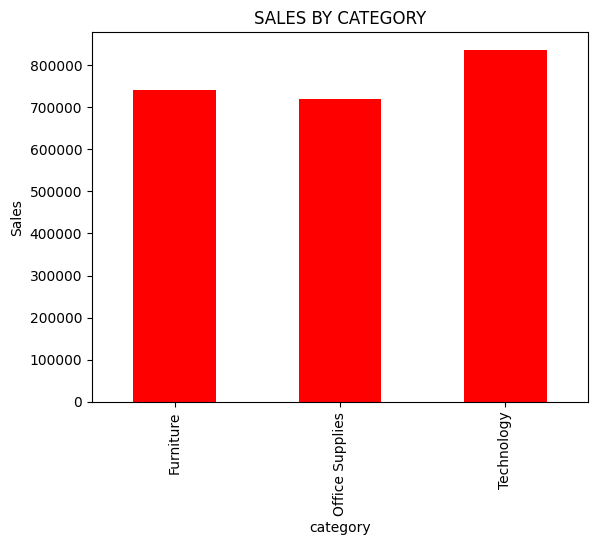

In [ ]:
# CATEGORY SALES CHART
category_analysis['Sales'].plot(kind='bar',title='SALES BY CATEGORY',color='red')
plt.xlabel('category')
plt.ylabel('Sales')
plt.show()

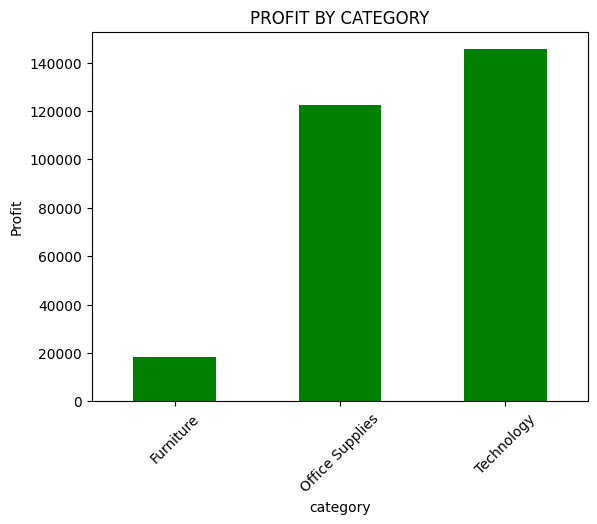

In [ ]:
# PROFIT BY CATEGORY (BAR CHART)
category_analysis['Profit'].plot(kind='bar',title='PROFIT BY CATEGORY',color='green')
plt.xlabel('category')
plt.ylabel('Profit')
plt.xticks(rotation=45)
plt.show()

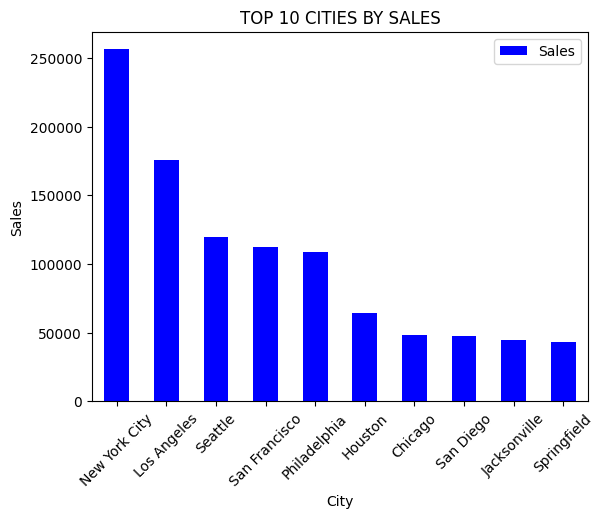

In [ ]:
#TOP 10 CITIES BY SALES
city_sales_top10=city_sales.sort_values(by='Sales',ascending=False).head(10)

city_sales_top10.plot(kind='bar',title='TOP 10 CITIES BY SALES',color='blue')
plt.xlabel('City')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

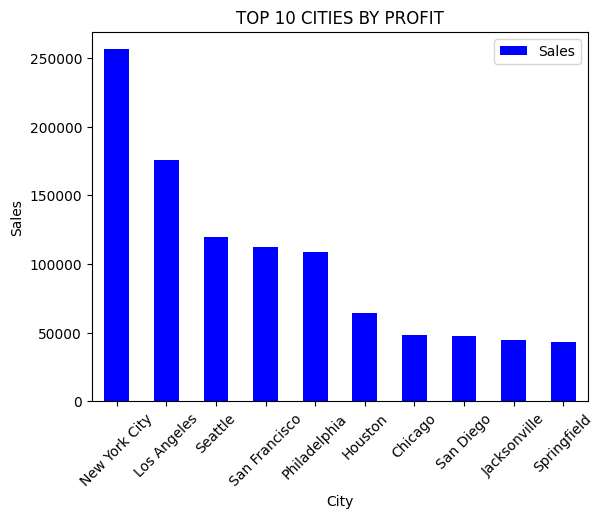

In [ ]:
# profit by category


city_profit_top10=city_sales.sort_values(by='Sales',ascending=False).head(10)

city_profit_top10.plot(kind='bar',title='TOP 10 CITIES BY PROFIT',color='blue')
plt.xlabel('City')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# loss making sub cat
loss_subcat=subcategory_analysis[subcategory_analysis['Profit'] <0].sort_values(by='Profit')
print(loss_subcat)

                  Sales    Profit
Sub_Category                     
Tables        206965.68 -17725.59
Bookcases     114880.05  -3472.56
Supplies       46673.52  -1188.99


In [ ]:
# BEST STATE PERFORMANCE(top 10)
sates=df.groupby('State')[['Sales','Profit']].sum()

print(sates)

                          Sales    Profit
State                                    
Alabama                19510.64   5786.85
Arizona                35282.02  -3427.87
Arkansas               11678.13   4008.65
California            457576.32  76331.00
Colorado               32108.12  -6527.86
Connecticut            13384.36   3511.44
Delaware               27451.07   9977.37
District of Columbia    2865.02   1059.59
Florida                89473.73  -3399.25
Georgia                49095.84  16250.08
Idaho                   4382.49    826.73
Illinois               80162.60 -12601.65
Indiana                53555.36  18382.97
Iowa                    4579.76   1183.81
Kansas                  2914.31    836.45
Kentucky               36591.75  11199.70
Louisiana               9217.03   2196.09
Maine                   1270.53    454.50
Maryland               23705.52   7031.20
Massachusetts          28634.44   6785.55
Michigan               75879.64  24428.05
Minnesota              29863.15  1

In [ ]:
sates.sort_values(by='Sales',ascending=False).head(10)

,Sales,Profit
State,,
California,457576.32,76331.00
New York,310827.08,74015.55
Texas,170124.48,-25750.91
Washington,138560.83,33368.29
Pennsylvania,116496.47,-15565.48
Florida,89473.73,-3399.25
Illinois,80162.60,-12601.65
Ohio,77976.84,-16959.31
Michigan,75879.64,24428.05


In [ ]:
sates.sort_values(by='Profit',ascending=False).head(10)

,Sales,Profit
State,,
California,457576.32,76331.00
New York,310827.08,74015.55
Washington,138560.83,33368.29
Michigan,75879.64,24428.05
Virginia,70636.72,18598.00
Indiana,53555.36,18382.97
Georgia,49095.84,16250.08
Kentucky,36591.75,11199.70
Minnesota,29863.15,10823.22


In [ ]:
loss_subcat.head(3)

,Sales,Profit
Sub_Category,,
Tables,206965.68,-17725.59
Bookcases,114880.05,-3472.56
Supplies,46673.52,-1188.99


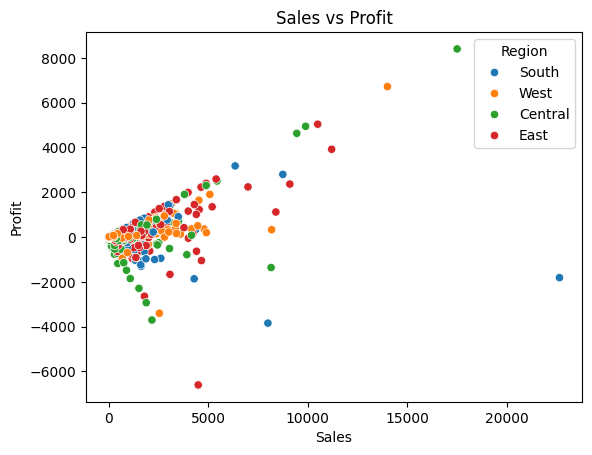

In [ ]:
#USING seaborn

sns.scatterplot(x='Sales',y='Profit',hue='Region',data=df)
plt.title('Sales vs Profit')
plt.show()

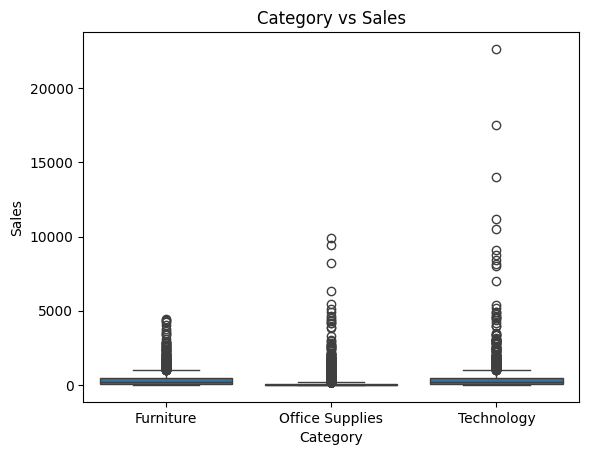

In [ ]:
sns.boxplot(x='Category',y='Sales',data=df)
plt.title('Category vs Sales')
plt.show()

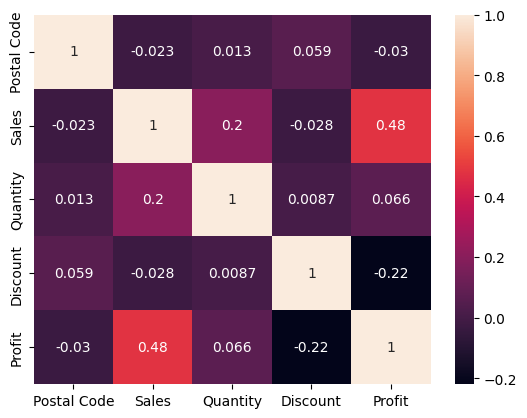

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [ ]:
# SALES ANALYSIS SUMMARY

print("Total Sales: ", total_sales)
print("Total Profit: ", total_profit)
print("Average Sales: ", round(average,2))
print("Total Quantity: ", total_quantity)
print("Profit Margin: ", round(profit_margin,2))
print("best profit_cat:" ,best_profit_category)
print("best sales_cat:" ,best_sales_category)
print("best profit_region:" ,best_profit_region)
print("best sales_region:" ,best_sales_region)
print("best profit_segment:" ,best_profit_segment)
print("best sales_segment:" ,best_sales_segment)
print("best profit_subcat:" ,best_profit_subcat)
print("best sales_subcat:" ,best_sales_subcat)


Total Sales:  2296195.81
Total Profit:  286242.2
Average Sales:  230.15
Total Quantity:  37820
Profit Margin:  12.47
best profit_cat: Consumer
best sales_cat: Technology
best profit_region: West
best sales_region: West
best profit_segment: Consumer
best sales_segment: Consumer
best profit_subcat: Copiers
best sales_subcat: Phones
